--- Model Accuracies ---
Linear SVM (C=1): 82.5%
Model A (RBF, γ=0.1, C=1): 85.0%
Model B (RBF, γ=1, C=1): 97.5%
Model C (RBF, γ=5, C=10): 97.5%


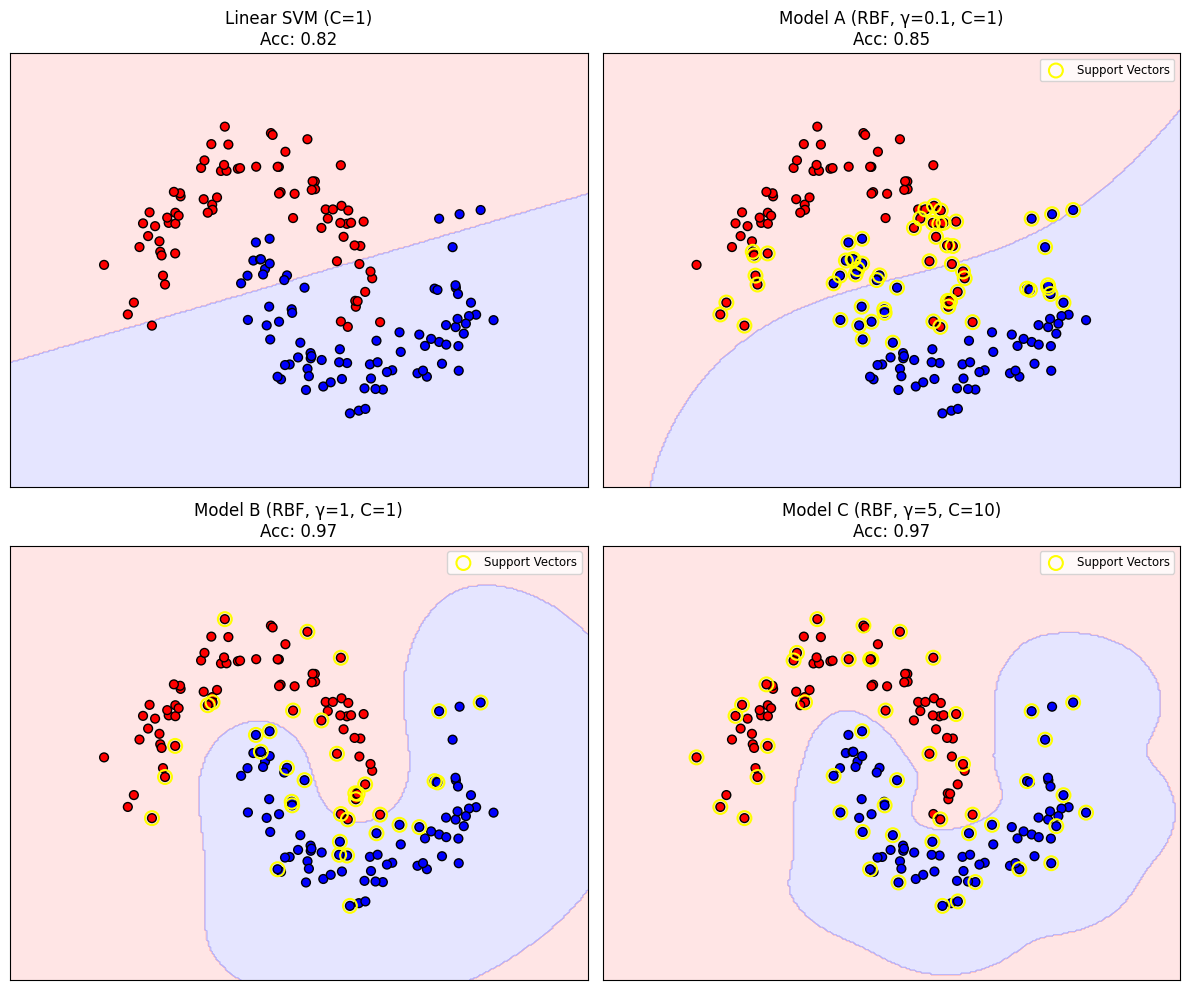

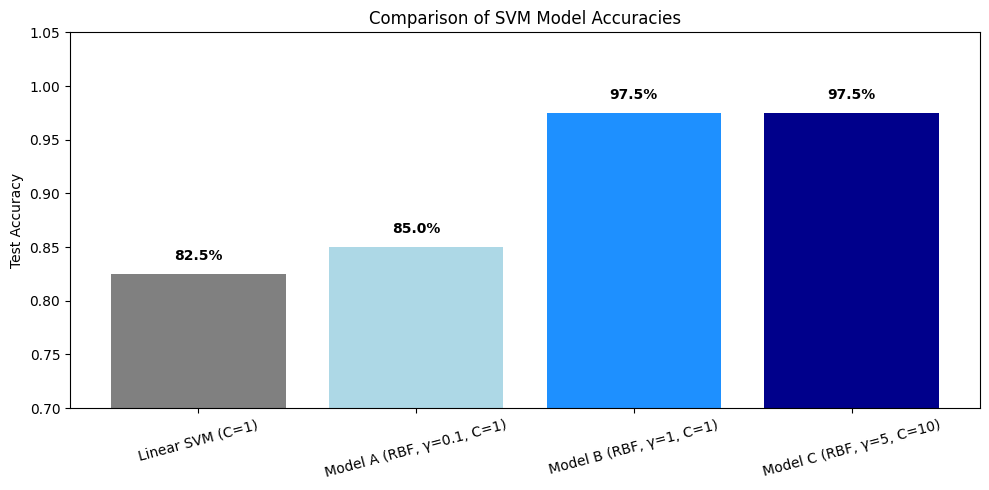

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear SVM (C=1)": SVC(kernel="linear", C=1),
    "Model A (RBF, γ=0.1, C=1)": SVC(kernel="rbf", gamma=0.1, C=1),
    "Model B (RBF, γ=1, C=1)": SVC(kernel="rbf", gamma=1, C=1),
    "Model C (RBF, γ=5, C=10)": SVC(kernel="rbf", gamma=5, C=10)
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

print("--- Model Accuracies ---")
for name, acc in accuracies.items():
    print(f"{name}: {acc * 100:.1f}%")

def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolors='k', s=40)
    
    if model.kernel != 'linear':
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='yellow', 
                   s=100, linewidth=1.5, label='Support Vectors')
        ax.legend(loc='upper right', fontsize='small')

    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    plot_decision_boundary(axes[i], model, X_train_scaled, y_train, f"{name}\nAcc: {accuracies[name]:.2f}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
names = list(accuracies.keys())
scores = list(accuracies.values())

bars = plt.bar(names, scores, color=['grey', 'lightblue', 'dodgerblue', 'darkblue'])
plt.ylim(0.7, 1.05)
plt.ylabel('Test Accuracy')
plt.title('Comparison of SVM Model Accuracies')
plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()